[Course Index](../00_Start_Here.ipynb)  |  [Next: Architecture 2: Layered, Hexagonal and MVC](02_Layered_Hexagonal_and_MVC.ipynb)

# Architecture 1: Monolith and Modular Monolith

Design patterns arrange objects inside a program. Architecture patterns arrange the program itself: what is deployed, what talks to what, and where the boundaries are.
We start with the shape almost every system begins as.

**Learning objectives.** After this module you can:

* say precisely what a monolith is and what its real advantages are;
* show, with a dependency graph, how a monolith degrades into a "big ball of mud";
* turn it into a modular monolith by enforcing module boundaries with a rule checker;
* explain deployment blast radius with a simulation.

## 1. The monolith

**Definition.** One deployable unit, one process, one codebase, usually one database. Every feature is a function call away from every other.

**Why it is good.** No network between parts, one thing to run and debug, transactions across features are ordinary, refactoring is a rename.
Most successful systems started as one, and many should stay one for years.

Here is a tiny shop as a monolith. Each "module" is a group of functions; they call each other freely.

charged ada 30.00; shipped lamp to ada


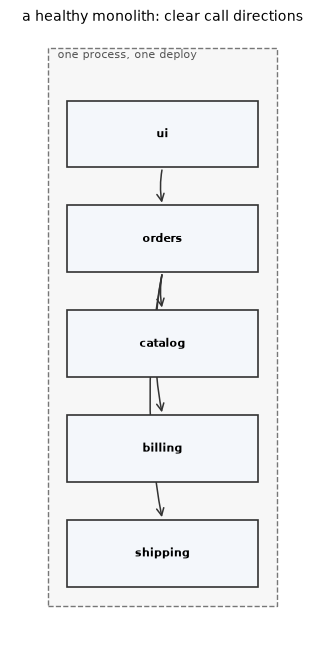

In [1]:
from dplab import component_diagram, check_dependencies, traced, trace

# --- catalog module ---
PRODUCTS = {"lamp": 25.0, "chair": 80.0}
def price_of(item):            return PRODUCTS[item]

# --- billing module ---
INVOICES = []
def charge(customer, amount):  INVOICES.append((customer, amount)); return f"charged {customer} {amount:.2f}"

# --- shipping module ---
SHIPMENTS = []
def ship(customer, item):      SHIPMENTS.append((customer, item)); return f"shipped {item} to {customer}"

# --- orders module: calls the others directly ---
def place_order(customer, item):
    total = price_of(item) * 1.2               # tax
    receipt = charge(customer, total)
    return receipt + "; " + ship(customer, item)

print(place_order("ada", "lamp"))

modules = ["ui", "orders", "catalog", "billing", "shipping"]
calls = [("ui", "orders"), ("orders", "catalog"), ("orders", "billing"), ("orders", "shipping")]
component_diagram(modules, calls, groups={"one process, one deploy": modules}, title="a healthy monolith: clear call directions")

## 2. How it rots: the big ball of mud

Nothing stops billing from reading the catalog's dict, or shipping from appending to invoices "just this once". Each shortcut is locally reasonable.
After a few years the dependency graph is complete, every change can break anything, and the only safe deploy is no deploy.

The simulation adds one random shortcut per month and measures the **change ripple**: how many modules can be affected by a change to one module (everything reachable in the graph).

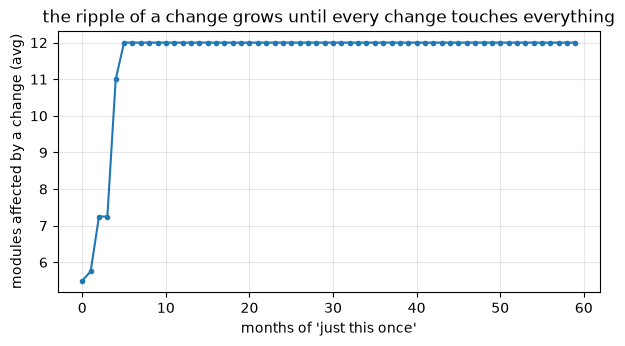

In [2]:
import random
import matplotlib.pyplot as plt

def reachable(graph, start):
    seen, stack = set(), [start]
    while stack:
        node = stack.pop()
        for nxt in graph.get(node, ()):
            if nxt not in seen:
                seen.add(nxt); stack.append(nxt)
    return seen

def ripple(graph, modules):
    # average number of modules that depend (directly or indirectly) on a given module
    reverse = {m: set() for m in modules}
    for src, dsts in graph.items():
        for d in dsts:
            reverse[d].add(src)
    return sum(len(reachable(reverse, m)) for m in modules) / len(modules)

random.seed(4)
modules = [f"m{i}" for i in range(12)]
graph = {m: set() for m in modules}
for i in range(1, 12):                             # start layered: each module uses one below it
    graph[modules[i]].add(modules[i - 1])
months, ripples = [], []
for month in range(60):
    if month:
        a, b = random.sample(modules, 2)           # one shortcut per month
        graph[a].add(b)
    months.append(month); ripples.append(ripple(graph, modules))

plt.figure(figsize=(7, 3.4))
plt.plot(months, ripples, "o-", markersize=3)
plt.xlabel("months of 'just this once'"); plt.ylabel("modules affected by a change (avg)")
plt.title("the ripple of a change grows until every change touches everything"); plt.grid(alpha=0.3); plt.show()

> **What to notice.** After a few dozen shortcuts, changing any module can affect nearly all twelve. The code did not get worse line by line; the *graph* did.

## 3. The modular monolith

Keep the single deployable. Add two rules and a checker:

1. Each module exposes a small **public API** (a facade, Module GoF 3) and everything else is private.
2. Modules may only depend on the modules listed for them, and the graph must have no cycles.

The checker below is a few lines and can run in CI. It is the whole difference between "modular" and "big ball of mud".

violations: [('billing', 'catalog'), ('shipping', 'billing')]


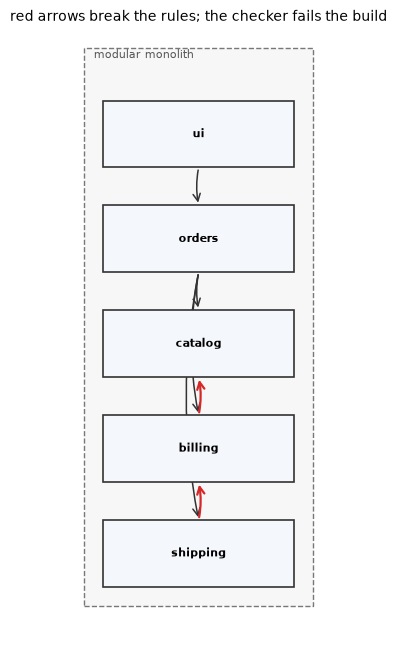

In [3]:
# What each module actually imports (in a real codebase you would scan the import statements)
deps = {
    "ui":       {"orders"},
    "orders":   {"catalog", "billing", "shipping"},
    "catalog":  set(),
    "billing":  {"catalog"},              # shortcut: billing reads product prices directly
    "shipping": {"billing"},              # shortcut: shipping appends to invoices
}
allowed = {"ui": {"orders"}, "orders": {"catalog", "billing", "shipping"}, "catalog": set(), "billing": set(), "shipping": set()}

violations = check_dependencies(deps, allowed)
print("violations:", violations)
edges = [(m, d) for m, ds in deps.items() for d in sorted(ds)]
component_diagram(list(deps), edges, groups={"modular monolith": list(deps)}, bad_edges=set(violations),
                  title="red arrows break the rules; the checker fails the build")

In [4]:
# Fixing a violation: billing needs the price, so orders passes it in. Now billing depends on nothing.
def charge_v2(customer, amount):
    INVOICES.append((customer, amount)); return f"charged {customer} {amount:.2f}"

def place_order_v2(customer, item):
    total = price_of(item) * 1.2
    return charge_v2(customer, total) + "; " + ship(customer, item)

deps["billing"] = set(); deps["shipping"] = set()
print("violations after the fix:", check_dependencies(deps, allowed))

violations after the fix: []


## 4. Blast radius: one deploy, one failure domain

In a monolith a crash anywhere is a crash everywhere: one process serves every request. The simulation below sends requests to a shop where one module has a bug that
throws on a fraction of calls. Compare the failure rates of requests that never even touch the buggy module.

In [5]:
import random
random.seed(7)

def run_monolith(requests, bug_rate):
    ok = {"browse": 0, "order": 0}; total = {"browse": 0, "order": 0}
    for _ in range(requests):
        kind = random.choice(["browse", "browse", "order"])
        total[kind] += 1
        if random.random() < bug_rate:          # the shipping bug takes the whole process down for this request
            continue
        ok[kind] += 1
    return {k: ok[k] / total[k] for k in ok}

def run_separate(requests, bug_rate):
    ok = {"browse": 0, "order": 0}; total = {"browse": 0, "order": 0}
    for _ in range(requests):
        kind = random.choice(["browse", "browse", "order"])
        total[kind] += 1
        if kind == "order" and random.random() < bug_rate:   # only orders touch shipping
            continue
        ok[kind] += 1
    return {k: ok[k] / total[k] for k in ok}

print("shipping bug crashes 5% of calls it is part of")
print("  monolith, one process:      ", {k: f"{v:.1%}" for k, v in run_monolith(20000, 0.05).items()})
print("  shipping isolated (preview):", {k: f"{v:.1%}" for k, v in run_separate(20000, 0.05).items()})

shipping bug crashes 5% of calls it is part of
  monolith, one process:       {'browse': '95.0%', 'order': '95.0%'}
  shipping isolated (preview): {'browse': '100.0%', 'order': '94.8%'}


> **What to notice.** In the monolith the browsing pages fail as often as orders do, though browsing never calls shipping. Isolation of failure is one of the real
> arguments for splitting a system, and Module 3 shows what it costs.

## Try it yourself

**Exercise 1.** Add a `reviews` module that `ui` and `catalog` may use. Write its `allowed` entry and make sure the checker passes. Then add a cycle on purpose and see the violation.

**Exercise 2.** Extend `check_dependencies` to detect cycles (a module reachable from itself). Hint: `reachable` from Section 2.

**Exercise 3.** Re-run the ripple simulation with a rule that rejects shortcuts pointing "upward" (from a lower-numbered module to a higher one). How does the curve change?

**Exercise 4 (challenge).** Write a script that builds `deps` from real `import` statements in a folder of Python files using the `ast` module.

<details><summary>Solutions</summary>

```python
# Exercise 2
def find_cycles(deps):
    return sorted(m for m in deps if m in reachable(deps, m))
print(find_cycles({"a": {"b"}, "b": {"a"}, "c": set()}))

# Exercise 3: with only downward shortcuts the graph stays acyclic and the ripple plateaus far lower.

# Exercise 4
import ast, pathlib
def scan(folder):
    deps = {}
    for path in pathlib.Path(folder).glob("*.py"):
        tree = ast.parse(path.read_text())
        names = {n.names[0].name.split(".")[0] for n in ast.walk(tree) if isinstance(n, ast.Import)}
        names |= {n.module.split(".")[0] for n in ast.walk(tree) if isinstance(n, ast.ImportFrom) and n.module}
        deps[path.stem] = names
    return deps
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [6]:
from dplab import quiz

quiz('arch1')

Checkpoint quiz, Architecture 1 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. A monolith is
    a) an old application
    b) one deployable unit that contains all the functionality
    c) a database
    d) a service mesh

Q2. The main risk as a monolith grows is
    a) it uses more CPU
    b) dependencies between parts tangle until every change is risky
    c) it cannot use a database
    d) it cannot be tested

Q3. A modular monolith
    a) splits the app into services
    b) keeps one deployable but enforces module boundaries with explicit interfaces
    c) removes the database
    d) has no modules

Q4. Shipping a one-line fix in a monolith means
    a) deploying only that line
    b) redeploying the whole application
    c) restarting the database
    d) nothing


## Key takeaways

* A monolith is one deployable. Its strengths are real: no network, easy transactions, cheap refactoring.
* It rots through the dependency graph, not through any single line. Measure the ripple.
* A modular monolith adds public module APIs and an enforced dependency rule; the checker is a few lines and belongs in CI.
* One process means one failure domain; that is the honest cost, and the first reason people split.

**Next:** rules for the arrows inside a module. [Architecture 2](02_Layered_Hexagonal_and_MVC.ipynb).

[Course Index](../00_Start_Here.ipynb)  |  [Next: Architecture 2: Layered, Hexagonal and MVC](02_Layered_Hexagonal_and_MVC.ipynb)